<a href="https://colab.research.google.com/github/jdasam/ant5015/blob/2026/notebooks/11th_week_nsynth_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 14: NSynth Autoencoder — Live Coding

In this session we will:
1. Understand **Conv2d** and **ConvTranspose2d** with a visual example
2. Build a **convolutional autoencoder** that encodes audio spectrograms
3. Load **pretrained weights** and listen to reconstructed audio
4. Explore the **latent space** through pitch manipulation and audio interpolation


In [1]:
import torch
import torch.nn as nn
import torchaudio
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import IPython.display as ipd
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np


---
## Section 1: Load the NSynth Dataset

NSynth is a large-scale audio dataset of musical notes created by Google Magenta.
Each sample is a 4-second monophonic note at a specific pitch.
We use only the **test split** (~4000 samples) to keep download time short.


In [2]:
!wget -q http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz


In [3]:
!tar -xf nsynth-test.jsonwav.tar.gz


### NSynthDataset class

The dataset class loads `.wav` files on demand and returns `(audio, pitch)` pairs.
`pitch` is a MIDI note number (0-127) stored in the metadata JSON.


In [4]:
class NSynthDataSet:
    def __init__(self, path):
        if isinstance(path, str):
            path = Path(path)
        self.path = path
        self.meta = pd.read_json(path / 'examples.json')
        self.file_list = list(self.path.rglob('*.wav'))

    def __getitem__(self, idx):
        fn = self.file_list[idx]
        audio, sr = torchaudio.load(fn)
        pitch = self.meta[fn.stem]['pitch']
        pitch = torch.tensor(pitch, dtype=torch.long)
        return audio, pitch

    def __len__(self):
        return len(self.meta.keys())


dataset = NSynthDataSet(Path('nsynth-test'))
print(f'Dataset size: {len(dataset)} samples')


Dataset size: 4096 samples


In [5]:
# Listen to a random sample
audio, pitch = dataset[10]
print(f'Audio shape: {audio.shape}, Pitch (MIDI): {pitch.item()}')
ipd.Audio(audio, rate=16000)


Audio shape: torch.Size([1, 64000]), Pitch (MIDI): 24


In [6]:
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)
batch = next(iter(train_loader))
audio, pitch = batch
print(f'Batch audio shape: {audio.shape}, pitch: {pitch}')


Batch audio shape: torch.Size([2, 1, 64000]), pitch: tensor([30, 93])


---
## Section 2: Conv2d and ConvTranspose2d

Before building the autoencoder, let's visualize how these two operations work.

- **Conv2d** (convolution): *reduces* spatial resolution — used in the **encoder**
- **ConvTranspose2d** (transposed convolution): *increases* spatial resolution — used in the **decoder**

Output size formula for **Conv2d**:

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \cdot padding - kernel\_size}{stride} \right\rfloor + 1$$

Output size formula for **ConvTranspose2d**:

$$H_{out} = (H_{in} - 1) \cdot stride - 2 \cdot padding + kernel\_size$$


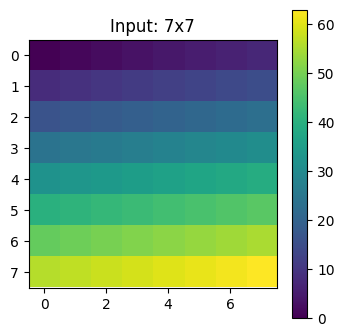

Input shape: torch.Size([1, 1, 8, 8])


In [18]:
# Create a simple 7x7 input with values 0-48
dummy = torch.arange(64).view(1, 1, 8, 8).to(torch.float)
plt.figure(figsize=(4, 4))
plt.imshow(dummy[0, 0], cmap='viridis')
plt.colorbar()
plt.title('Input: 7x7')
plt.show()
print(f'Input shape: {dummy.shape}')


Conv2d output shape: torch.Size([1, 1, 3, 3])


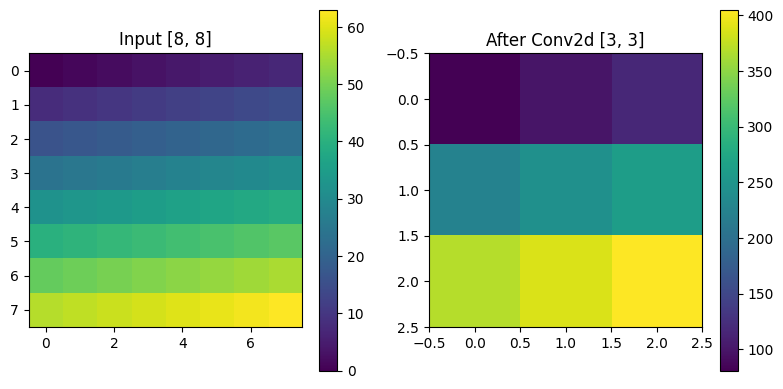

In [19]:
# Conv2d: downsampling
kernel_size = 3
stride = 2
padding = 0

conv_layer = nn.Conv2d(1, 1, kernel_size, stride=stride, padding=padding)
conv_layer.weight.data = torch.ones_like(conv_layer.weight)  # sum-pooling kernel
conv_layer.bias.data.zero_()

conv_out = conv_layer(dummy)
print(f'Conv2d output shape: {conv_out.shape}')

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(dummy[0, 0], cmap='viridis')
plt.title(f'Input {list(dummy.shape[2:])}')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(conv_out.squeeze().detach(), cmap='viridis')
plt.title(f'After Conv2d {list(conv_out.shape[2:])}')
plt.colorbar()
plt.tight_layout()
plt.show()


### Exercise 1: ConvTranspose2d

Apply `nn.ConvTranspose2d` to the Conv2d output to **upsample** it back toward the original size.
Try different `stride` and `kernel_size` values and observe how the output shape changes.

The output shape formula is:  
`H_out = (H_in - 1) * stride - 2 * padding + kernel_size`

**Task**: Run the cell and verify that ConvTranspose2d approximately reverses the Conv2d.


ConvTranspose2d output shape: torch.Size([1, 1, 7, 7])


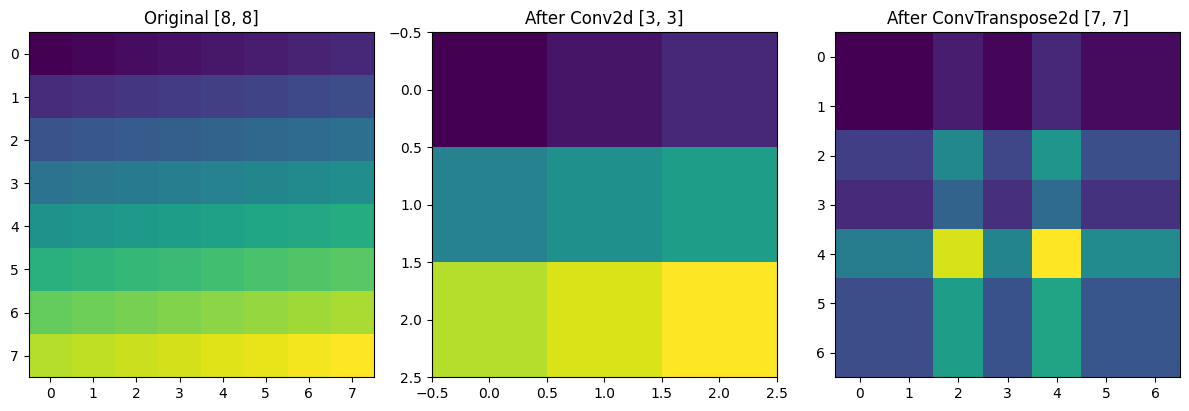

In [21]:
# Try changing stride, kernel_size, and padding to observe the shape changes
t_kernel_size = 3
t_stride = 2      # try 1, 2, 3
t_padding = 0     # try 0, 1

transpose_layer = nn.ConvTranspose2d(
    in_channels=1,
    out_channels=1,
    kernel_size=t_kernel_size,
    stride=t_stride,
    padding=t_padding
)
transpose_layer.weight.data = torch.ones_like(transpose_layer.weight.data)
transpose_layer.bias.data.zero_()

t_out = transpose_layer(conv_out)
print(f'ConvTranspose2d output shape: {t_out.shape}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(dummy[0, 0].detach(), cmap='viridis')
plt.title(f'Original {list(dummy.shape[2:])}')
plt.subplot(1, 3, 2)
plt.imshow(conv_out.squeeze().detach(), cmap='viridis')
plt.title(f'After Conv2d {list(conv_out.shape[2:])}')
plt.subplot(1, 3, 3)
plt.imshow(t_out.squeeze().detach(), cmap='viridis')
plt.title(f'After ConvTranspose2d {list(t_out.shape[2:])}')
plt.tight_layout()
plt.show()


---
## Section 3: Build the NSynth Autoencoder

The autoencoder has three main components:

| Component | Role |
|-----------|------|
| `SpecModel` | Converts raw audio waveform into a log-magnitude spectrogram |
| `Encoder` | Stack of Conv2d blocks that compress the spectrogram into a latent vector |
| `Decoder` | Stack of ConvTranspose2d blocks that reconstruct the spectrogram from latent + pitch |

The latent vector is **fused with a pitch embedding** before decoding,
so the model can synthesize the same timbre at any target pitch.

```
audio --> SpecModel --> Encoder --> Linear --> latent
                                                  |
                              pitch_embedding ----+
                                                  |
                              [concat] --> Decoder --> recon_spec
```


### 3.1 SpecModel: Audio to Spectrogram

We use an STFT spectrogram (n_fft=1024, hop_length=256) converted to the dB scale.
Output shape: `(batch, 1, freq_bins, time_frames)`


In [22]:
class SpecModel(nn.Module):
    def __init__(self, n_fft, hop_length):
        super().__init__()
        self.spec_converter = torchaudio.transforms.Spectrogram(n_fft=n_fft, hop_length=hop_length)
        self.db_converter = torchaudio.transforms.AmplitudeToDB(stype='power')

    def forward(self, audio_sample):
        spec = self.spec_converter(audio_sample)
        db_spec = self.db_converter(spec)
        return db_spec


### 3.2 Building Blocks

`Conv2dNormPool` is a reusable encoder block: **Conv2d -> BatchNorm -> LeakyReLU**.

`Conv2dNormTransposePool` swaps Conv2d for ConvTranspose2d for use in the decoder.
Since the normalization and activation are the same, we use **inheritance** to avoid repeating code.


In [24]:
class Conv2dNormPool(nn.Module):
    """Encoder block: Conv2d + BatchNorm2d + LeakyReLU."""
    def __init__(self, in_channels, out_channels, kernel_size, padding, stride):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels, out_channels=out_channels,
            kernel_size=kernel_size, padding=padding, stride=stride
        )
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        return x


class Conv2dNormTransposePool(Conv2dNormPool):
    """Decoder block: ConvTranspose2d + BatchNorm2d + LeakyReLU.

    Inherits BatchNorm and activation from Conv2dNormPool;
    replaces Conv2d with ConvTranspose2d to upsample instead of downsample.
    """
    def __init__(self, in_channels, out_channels, kernel_size, padding, stride):
        super().__init__(in_channels, out_channels, kernel_size, padding, stride)
        # Override self.conv with a transposed version
        self.conv = nn.ConvTranspose2d(
            in_channels=in_channels, out_channels=out_channels,
            kernel_size=kernel_size, padding=padding, stride=stride
        )


### 3.3 AutoEncoder

Channel progression in the encoder:  
`1 -> 128 -> 128 -> 128 -> 256 -> 256 -> 256 -> 512 -> 512 -> 1024`

The decoder mirrors this in reverse.

After building the model, we load **pretrained weights** (Section 4),
so the architecture here must exactly match what was used during training.


In [25]:
class AutoEncoder(nn.Module):
    def __init__(self, n_fft, hop_length, hidden_size=256):
        super().__init__()
        self.spec_model = SpecModel(n_fft, hop_length)

        # Pitch embedding: MIDI pitch 0-120 -> hidden_size // 2 dim vector
        self.pitch_embedder = nn.Embedding(121, hidden_size // 2)

        # Channel sizes for encoder layers (index 0 = input, index -1 = bottleneck)
        self.num_channels = [1] + [128] * 3 + [256] * 3 + [512] * 2 + [1024]

        # ── Encoder ──────────────────────────────────────────────────────────
        self.encoder = nn.Sequential()
        # Layer 0: larger 5x5 kernel to capture broader context
        self.encoder.add_module('conv_norm0',
            Conv2dNormPool(self.num_channels[0], self.num_channels[1],
                           kernel_size=(5, 5), padding=2, stride=(2, 2)))
        # Layers 1-6: standard 4x4 downsampling blocks
        for i in range(1, 7):
            self.encoder.add_module(f'conv_norm{i}',
                Conv2dNormPool(self.num_channels[i], self.num_channels[i + 1],
                               kernel_size=(4, 4), padding=1, stride=(2, 2)))
        # Layer 7: 2x2 kernel, no padding (final spatial compression)
        self.encoder.add_module('conv_norm7',
            Conv2dNormPool(self.num_channels[7], self.num_channels[8],
                           kernel_size=(2, 2), padding=0, stride=(2, 2)))
        # Layer 8: 1x1 pointwise convolution
        self.encoder.add_module('conv_norm8',
            Conv2dNormPool(self.num_channels[8], self.num_channels[9],
                           kernel_size=(1, 1), padding=0, stride=(1, 1)))

        # Flatten encoder output (batch, 1024, 1, 1) -> (batch, 1024) -> latent
        # hidden_size * 2 = 1024 * 2 when hidden_size=1024
        self.final_layer = nn.Linear(hidden_size * 2, hidden_size)

        # ── Decoder ──────────────────────────────────────────────────────────
        # Decoder input: latent (hidden_size) + pitch_emb (hidden_size//2)
        # Total input channels = num_channels[-1] + hidden_size//2
        self.decoder = nn.Sequential(
            Conv2dNormTransposePool(
                in_channels=self.num_channels[-1] + hidden_size // 2,
                out_channels=self.num_channels[-2],
                kernel_size=(2, 1), padding=0, stride=(2, 2)
            )
        )
        # Mirror encoder layers in reverse order
        self.decoder.add_module('conv_norm0',
            Conv2dNormTransposePool(self.num_channels[-2], self.num_channels[-3],
                                    kernel_size=(2, 2), padding=0, stride=(2, 2)))
        for i in range(1, 7):
            self.decoder.add_module(f'conv_norm{i}',
                Conv2dNormTransposePool(self.num_channels[-2 - i], self.num_channels[-3 - i],
                                        kernel_size=(4, 4), padding=1, stride=(2, 2)))
        # Final layer: output 1-channel spectrogram
        self.decoder.add_module('final_module',
            nn.ConvTranspose2d(self.num_channels[1], 1,
                               kernel_size=(4, 4), padding=1, stride=(2, 2)))

    def forward(self, x, pitch):
        """x: (batch, 1, time)  pitch: (batch,) LongTensor"""
        # Step 1: Convert audio to spectrogram
        spec = self.spec_model(x)
        spec = spec[:, :, :-1]   # drop last freq bin to get exactly 512 bins
        spec /= 80               # normalize dB range to roughly [-1, 1]
        spec = nn.functional.pad(spec, (2, 3), value=torch.min(spec))  # pad time to 512

        # Step 2: Encode spectrogram to latent vector
        out = self.encoder(spec)                          # (batch, 1024, 1, 1)
        latent = self.final_layer(out.view(out.shape[0], -1))  # (batch, hidden_size)

        # Step 3: Fuse latent with pitch embedding
        pitch_emb = self.pitch_embedder(pitch)            # (batch, hidden_size // 2)
        fused = torch.cat([latent, pitch_emb], dim=-1)   # (batch, hidden_size + hidden_size // 2)
        fused = fused.view(fused.shape[0], -1, 1, 1)     # reshape for decoder

        # Step 4: Decode to reconstructed spectrogram
        recon_spec = self.decoder(fused)                  # (batch, 1, 512, 512)

        return recon_spec, spec


# Instantiate and run a quick sanity check
model = AutoEncoder(n_fft=1024, hop_length=256, hidden_size=1024)
with torch.no_grad():
    recon_spec, spec = model(audio, pitch)
print(f'Spectrogram shape:           {spec.shape}')
print(f'Reconstructed spec shape:    {recon_spec.shape}')


Spectrogram shape:           torch.Size([2, 1, 512, 256])
Reconstructed spec shape:    torch.Size([2, 1, 512, 256])


### 3.4 Walkthrough: Step-by-step Forward Pass

Let's trace the shapes manually through each stage of the encoder.
This is useful for debugging and for understanding the bottleneck dimension.


In [26]:
x = audio
self = model

print(f'[Input]       audio shape:      {x.shape}')

spec = self.spec_model(x)
print(f'[SpecModel]   spectrogram:      {spec.shape}')

spec = spec[:, :, :-1]
print(f'[Trim]        after trim:       {spec.shape}')

spec /= 80
print(f'[Normalize]   spec median:      {torch.median(spec):.4f}')

spec = nn.functional.pad(spec, (2, 3), value=torch.min(spec))
print(f'[Pad]         after pad:        {spec.shape}')

encoder_out = self.encoder(spec)
print(f'[Encoder]     encoder output:   {encoder_out.shape}')

latent = self.final_layer(encoder_out.flatten(1))
print(f'[Linear]      latent:           {latent.shape}')

pitch_emb = self.pitch_embedder(pitch)
print(f'[PitchEmb]    pitch embedding:  {pitch_emb.shape}')

fused = torch.cat([latent, pitch_emb], dim=-1)
fused_4d = fused.view(fused.shape[0], -1, 1, 1)
print(f'[Fused]       decoder input:    {fused_4d.shape}')

recon_spec = self.decoder(fused_4d)
print(f'[Decoder]     recon spec:       {recon_spec.shape}')


[Input]       audio shape:      torch.Size([2, 1, 64000])
[SpecModel]   spectrogram:      torch.Size([2, 1, 513, 251])
[Trim]        after trim:       torch.Size([2, 1, 512, 251])
[Normalize]   spec median:      -0.9585
[Pad]         after pad:        torch.Size([2, 1, 512, 256])
[Encoder]     encoder output:   torch.Size([2, 1024, 2, 1])
[Linear]      latent:           torch.Size([2, 1024])
[PitchEmb]    pitch embedding:  torch.Size([2, 512])
[Fused]       decoder input:    torch.Size([2, 1536, 1, 1])
[Decoder]     recon spec:       torch.Size([2, 1, 512, 256])


### 3.5 Inspect the Decoder

Print the decoder structure to see all ConvTranspose2d layers.
Notice how the channel count *decreases* while spatial size *grows* — mirroring the encoder.


In [27]:
print(model.decoder)


Sequential(
  (0): Conv2dNormTransposePool(
    (conv): ConvTranspose2d(1536, 512, kernel_size=(2, 1), stride=(2, 2))
    (batch_norm): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): LeakyReLU(negative_slope=0.1)
  )
  (conv_norm0): Conv2dNormTransposePool(
    (conv): ConvTranspose2d(512, 512, kernel_size=(2, 2), stride=(2, 2))
    (batch_norm): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): LeakyReLU(negative_slope=0.1)
  )
  (conv_norm1): Conv2dNormTransposePool(
    (conv): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (batch_norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): LeakyReLU(negative_slope=0.1)
  )
  (conv_norm2): Conv2dNormTransposePool(
    (conv): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (batch_norm): BatchNorm2d(256, eps=1e-05, momentum=

---
## Section 4: Load a Pretrained Model

Training from scratch would take days on a GPU.
We load weights pretrained for ~1.8 million iterations on the full NSynth training set.

> **Note**: the architecture must exactly match the pretrained weights.
> That's why we kept the model structure fixed in Section 3.


In [28]:
!gdown 13it0VrccbE5QkdEGTlHZjSQFZLZTy1uu


Downloading...
From (original): https://drive.google.com/uc?id=13it0VrccbE5QkdEGTlHZjSQFZLZTy1uu
From (redirected): https://drive.google.com/uc?id=13it0VrccbE5QkdEGTlHZjSQFZLZTy1uu&confirm=t&uuid=80e97a03-a449-4173-bef1-7625f8067801
To: /content/autoencoder_last.pt
100% 67.5M/67.5M [00:01<00:00, 40.3MB/s]


In [29]:
pretrained_weights = torch.load('autoencoder_last.pt', map_location='cpu')
model.load_state_dict(pretrained_weights)
model.eval()
print('Pretrained weights loaded successfully.')


Pretrained weights loaded successfully.


---
## Section 5: Reconstruct Audio with the Pretrained Model

We encode a batch of samples and decode them back.
Compare the original and reconstructed spectrograms — they should look very similar.


In [30]:
print('Original audio:')
ipd.display(ipd.Audio(audio[1], rate=16000))


Original audio:


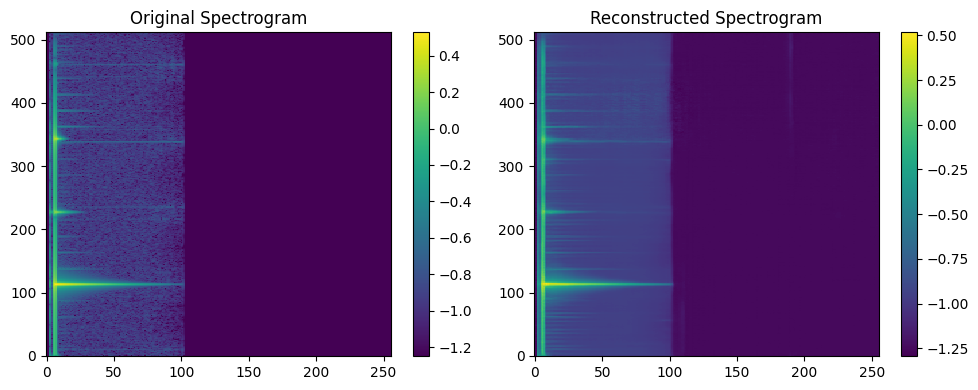

In [31]:
audio, pitch = batch

with torch.no_grad():
    recon_spec, spec = model(audio, pitch)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(spec[1, 0], origin='lower', interpolation='nearest', aspect='auto')
plt.title('Original Spectrogram')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(recon_spec[1, 0].detach(), origin='lower', interpolation='nearest', aspect='auto')
plt.title('Reconstructed Spectrogram')
plt.colorbar()
plt.tight_layout()
plt.show()


### 5.1 Griffin-Lim: Spectrogram to Waveform

The model outputs a **magnitude spectrogram** with no phase information.
We use the **Griffin-Lim algorithm** to iteratively estimate phase and reconstruct the waveform.

Steps inside `network_output_to_audio`:
1. Rescale normalized spectrogram back to dB (multiply by 80)
2. Pad the frequency axis (we dropped one bin earlier)
3. Convert dB -> linear amplitude
4. Run Griffin-Lim (100 iterations)


In [34]:
def network_output_to_audio(spec):
    """Convert normalized model output spectrogram to an audio waveform."""
    rescaled_spec = spec * 80
    padded_spec = nn.functional.pad(rescaled_spec, (0, 0, 0, 1), value=-100)
    magnitude_spec = torchaudio.functional.DB_to_amplitude(padded_spec, ref=1, power=1)
    griffin_lim = torchaudio.transforms.GriffinLim(n_fft=1024, hop_length=256, n_iter=100)
    return griffin_lim(magnitude_spec)


print('Original audio:')
ipd.display(ipd.Audio(audio[1], rate=16000))

# Original audio reconstructed through Griffin-Lim (for quality comparison)
org_audio = network_output_to_audio(spec[1])
print('Original (via Griffin-Lim):')
ipd.display(ipd.Audio(org_audio, rate=16000))

# Autoencoder reconstruction
recon_audio = network_output_to_audio(recon_spec[1])
print('Autoencoder reconstruction:')
ipd.display(ipd.Audio(recon_audio, rate=16000))


Original audio:


Original (via Griffin-Lim):


Autoencoder reconstruction:


---
## Section 6: Pitch Manipulation

Because the decoder receives a **pitch embedding** separately from the latent code,
we can change the pitch at inference time — without retraining.

**Experiment**: encode the audio with the true pitch, then decode with a shifted pitch.
The result should sound like the same instrument timbre at a different note.


In [48]:
audio, pitch = next(iter(train_loader))
print(f'Original pitches: {pitch}')
print('Sample A:')
ipd.display(ipd.Audio(audio[0], rate=16000))
print('Sample B:')
ipd.display(ipd.Audio(audio[1], rate=16000))


Original pitches: tensor([40, 45])
Sample A:


Sample B:


In [40]:
# Shift pitch up by 12 semitones (one octave)
shifted_pitch = (pitch + 12).clamp(0, 120)
print(f'Shifted pitches: {shifted_pitch}')

with torch.no_grad():
    recon_spec, spec = model(audio, shifted_pitch)

recon_audio = network_output_to_audio(recon_spec[1])
print('Pitch-shifted reconstruction (sample A, +1 octave):')
ipd.Audio(recon_audio, rate=16000)


Shifted pitches: tensor([100,  79])
Pitch-shifted reconstruction (sample A, +1 octave):


---
## Section 7: Latent Space Fusion (Audio Interpolation)

The latent vector captures **timbre** independently of pitch.
By interpolating between two latent vectors we can blend two timbres:

$$z_{mix} = \alpha \cdot z_a + (1 - \alpha) \cdot z_b$$

We need two helper functions:
- `get_latent(model, audio)` — encode audio to a latent vector (no pitch)
- `latent_to_spec(model, latent, pitch)` — decode latent + pitch to a spectrogram

**Exercise**: Study the `forward()` method and implement these two functions.


In [49]:
def get_latent(model, audio):
    """Encode audio to a latent vector (pitch-independent).

    Steps:
      1. Convert audio to spectrogram via model.spec_model
      2. Normalize (drop last freq bin, divide by 80, pad time axis)
      3. Pass through model.encoder
      4. Flatten and pass through model.final_layer
    """
    spec = model.spec_model(audio)
    spec = spec[:, :, :-1]
    spec /= 80
    spec = nn.functional.pad(spec, (2, 3), value=torch.min(spec))
    out = model.encoder(spec)
    latent = model.final_layer(out.view(out.shape[0], -1))
    return latent


with torch.no_grad():
    latent_vectors = get_latent(model, audio)

print(f'Latent vector shape: {latent_vectors.shape}')
vector_a = latent_vectors[0]
vector_b = latent_vectors[1]


Latent vector shape: torch.Size([2, 1024])


In [50]:
def latent_to_spec(model, latent, pitch):
    """Decode a latent vector + pitch to a spectrogram.

    Steps:
      1. Get pitch embedding via model.pitch_embedder
      2. Concatenate latent and pitch embedding
      3. Reshape to (batch, C, 1, 1) for the decoder
      4. Pass through model.decoder
    """
    pitch_emb = model.pitch_embedder(pitch)             # (batch, hidden_size // 2)
    fused = torch.cat([latent, pitch_emb], dim=-1)      # (batch, hidden_size + hidden_size // 2)
    fused = fused.view(fused.shape[0], -1, 1, 1)       # (batch, C, 1, 1)
    recon_spec = model.decoder(fused)
    return recon_spec


### 7.1 Interpolate Between Two Sounds

Change `alpha` to control the blend:
- `alpha = 1.0` -> pure sound A
- `alpha = 0.0` -> pure sound B
- `alpha = 0.5` -> equal mix


In [51]:
print('Sound A (original):')
ipd.display(ipd.Audio(audio[0], rate=16000))
print('Sound B (original):')
ipd.display(ipd.Audio(audio[1], rate=16000))


Sound A (original):


Sound B (original):


In [57]:
alpha = 0.5   # change this (0.0 to 1.0) and listen to the result

mixed_latent = alpha * vector_a + (1 - alpha) * vector_b
mixed_latent = mixed_latent.unsqueeze(0)  # add batch dimension

target_pitch = pitch[0:1]  # use pitch from sample A
print(f'Target pitch: {target_pitch.item()}')

with torch.no_grad():
    mixed_spec = latent_to_spec(model, mixed_latent, target_pitch+5)

mixed_audio = network_output_to_audio(mixed_spec)
print(f'Mixed audio (alpha={alpha}):')
ipd.Audio(mixed_audio.detach()[0], rate=16000)


Target pitch: 40
Mixed audio (alpha=0.5):


### 7.2 Decode the Same Timbre at Multiple Pitches

We can also fix the latent (timbre) and vary only the pitch embedding.
This should give us the same instrument sound across different notes.


In [59]:
# MIDI notes: C2=36, C3=48, C4=60, C5=72
target_pitches = torch.tensor([36, 48, 60, 72], dtype=torch.long)
latent_repeated = mixed_latent[0].unsqueeze(0).expand(4, -1)  # repeat latent for each pitch

with torch.no_grad():
    multi_spec = latent_to_spec(model, latent_repeated, target_pitches)

for i, p in enumerate(target_pitches):
    audio_out = network_output_to_audio(multi_spec[i:i + 1])
    print(f'MIDI pitch {p.item()} ({["C2","C3","C4","C5"][i]}):')
    ipd.display(ipd.Audio(audio_out.detach()[0], rate=16000))


MIDI pitch 36 (C2):


MIDI pitch 48 (C3):


MIDI pitch 60 (C4):


MIDI pitch 72 (C5):
